##**Assignment Title: Electric Vehicle Population Analysis**

This notebook explores the [Electric Vehicle Population Data](https://www.kaggle.com/datasets/ratikkakkar/electric-vehicle-population-data/data), focusing on trends in vehicle adoption, battery range, manufacturer distribution, pricing, and geographic spread.

This notebook presents key types of data visualizations to uncover insights from the electric vehicle (EV) dataset:

1. Relational plots — Show relationships between numeric variables like Model Year vs Electric Range for top manufacturers.
2. Categorical plots — Compare numeric features across categories, such as vehicles per manufacturer.
3. Statistical plots — Analyze distributions using violin plots, highlighting Electric Range by Vehicle Type.
4. Regression analysis — Fit linear, exponential, and polynomial models to study EV registration trends over time.
5. K-Means clustering — Segment vehicles by Electric Range and Base MSRP into groups like Budget, Mid-range, and Premium.

The goal is to highlight adoption patterns, identify popular manufacturers, and explore how vehicle range, price, and type vary across the market.

Dataset link: https://www.kaggle.com/datasets/ratikkakkar/electric-vehicle-population-data/data

## Data Preparation and Cleaning

The dataset was cleaned to ensure accuracy, handling missing values, duplicates, and formatting issues, making it ready for analysis.


In [242]:
# -----------------------------
# 1. Import Libraries
# -----------------------------
"""
Import necessary libraries for data manipulation and visualization.
"""
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples
from scipy import stats
from scipy.optimize import curve_fit

import warnings
warnings.filterwarnings("ignore")

In [206]:
# -----------------------------
# 2. Mount Google Drive
# -----------------------------
"""
Mount Google Drive to access the CSV file.
"""
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [207]:
# -----------------------------
# 3. Load Dataset
# -----------------------------
"""
Load EV population CSV file and display initial information.
"""
file_path = "/content/drive/MyDrive/Colab Notebooks/Electric_Vehicle_Population_Data.csv"
df = pd.read_csv(file_path)

# Preview
print("First 5 rows:")
display(df.head())

# Shape and columns
print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.info()

First 5 rows:


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,JTMEB3FV6N,Monroe,Key West,FL,33040,2022,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,0,NaN,198968248,POINT (-81.80023 24.5545),NaN,12087972100
1,1G1RD6E45D,Clark,Laughlin,NV,89029,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,NaN,5204412,POINT (-114.57245 35.16815),NaN,32003005702
2,JN1AZ0CP8B,Yakima,Yakima,WA,98901,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,0,15.0,218972519,POINT (-120.50721 46.60448),PACIFICORP,53077001602
3,1G1FW6S08H,Skagit,Concrete,WA,98237,2017,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,238,0,39.0,186750406,POINT (-121.7515 48.53892),PUGET SOUND ENERGY INC,53057951101
4,3FA6P0SU1K,Snohomish,Everett,WA,98201,2019,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26,0,38.0,2006714,POINT (-122.20596 47.97659),PUGET SOUND ENERGY INC,53061041500


Dataset shape: (112634, 17)
Columns: ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         112634 non-null  object 
 1   County                                             112634 non-null  object 
 2   City                                               112634 non-null  object 
 3   State                                              112634 non-null  object 
 4   Postal Code                                        112634 non

In [208]:
# -----------------------------
# 4. Drop Unnecessary Columns
# -----------------------------
"""
Drop columns that are not needed for analysis to reduce dataset complexity.
"""
cols_to_drop = [
    'Postal Code',
    'Legislative District',
    'Electric Utility',
    '2020 Census Tract'
]
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

In [209]:
# -----------------------------
# 5. Rename Columns
# -----------------------------
"""
Rename specific columns for clarity and consistency in naming.
"""
df.rename(
    columns={
        'Clean Alternative Fuel Vehicle (CAFV) Eligibility': 'cafv_eligibility',
        'Make': 'manufacturer'
    },
    inplace=True
)

print(df.columns)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Model Year', 'manufacturer',
       'Model', 'Electric Vehicle Type', 'cafv_eligibility', 'Electric Range',
       'Base MSRP', 'DOL Vehicle ID', 'Vehicle Location'],
      dtype='object')


In [210]:
# -------------------------------------------------------
# 6. Separate Numerical and Categorical Columns
# -------------------------------------------------------
"""
Identify numerical and categorical columns to facilitate cleaning and analysis.
"""
df_num = df.select_dtypes(include=['float64', 'int64'])
df_cat = df.select_dtypes(include=['object'])

print("Numerical columns:", df_num.columns.tolist())
print("Categorical columns:", df_cat.columns.tolist())

Numerical columns: ['Model Year', 'Electric Range', 'Base MSRP', 'DOL Vehicle ID']
Categorical columns: ['VIN (1-10)', 'County', 'City', 'State', 'manufacturer', 'Model', 'Electric Vehicle Type', 'cafv_eligibility', 'Vehicle Location']


In [211]:
# -----------------------------
# 7. Convert Categorical Columns
# -----------------------------
"""
Convert specific object columns to the 'category' data type.
"""
for col in df_cat.columns:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112634 entries, 0 to 112633
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   VIN (1-10)             112634 non-null  category
 1   County                 112634 non-null  category
 2   City                   112634 non-null  category
 3   State                  112634 non-null  category
 4   Model Year             112634 non-null  int64   
 5   manufacturer           112634 non-null  category
 6   Model                  112614 non-null  category
 7   Electric Vehicle Type  112634 non-null  category
 8   cafv_eligibility       112634 non-null  category
 9   Electric Range         112634 non-null  int64   
 10  Base MSRP              112634 non-null  int64   
 11  DOL Vehicle ID         112634 non-null  int64   
 12  Vehicle Location       112610 non-null  category
dtypes: category(9), int64(4)
memory usage: 5.2 MB


In [212]:
# -----------------------------
# 8. Handle Missing Values
# -----------------------------
"""
Identify and handle missing values in the dataset.
"""
# Check missing values before filling
missing_features = df.isnull().sum()
print("Missing values per column before filling:")
print(missing_features[missing_features > 0])

# Fill missing values for key categorical columns
for col in ['Model']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

# Drop rows with missing 'Vehicle Location'
df = df.dropna(subset=['Vehicle Location']).copy()

# Check missing values after filling
print("\nMissing values per column after filling:")
print(df.isnull().sum())

Missing values per column before filling:
Model               20
Vehicle Location    24
dtype: int64

Missing values per column after filling:
VIN (1-10)               0
County                   0
City                     0
State                    0
Model Year               0
manufacturer             0
Model                    0
Electric Vehicle Type    0
cafv_eligibility         0
Electric Range           0
Base MSRP                0
DOL Vehicle ID           0
Vehicle Location         0
dtype: int64


In [213]:
# -----------------------------
# 9. Replace zeros with median
# -----------------------------
def replace_zeros_with_median(df, column, by_type=None):
    """
    Replace 0 values in a column with the median.
    """

    # Replace 0 with NaN
    df[column].replace(0, pd.NA, inplace=True)

    if by_type:
        # Fill NaN with median per group
        median_by_group = df.groupby(by_type)[column].transform('median')
        df[column].fillna(median_by_group, inplace=True)
    else:
        # Fill NaN with overall median
        median_value = df[column].median()
        df[column].fillna(median_value, inplace=True)

    # Convert to integer type
    df[column] = df[column].astype('int64')

    return df

df = replace_zeros_with_median(df, 'Base MSRP')                                        # overall median
df = replace_zeros_with_median(df, 'Electric Range', by_type='Electric Vehicle Type')  # type-specific median

In [214]:
# -----------------------------------------------
# 10. Extract Coordinates from 'Vehicle Location'
# -----------------------------------------------
"""
Parse the 'Vehicle Location' column to extract longitude and latitude
"""
df['Latitude'] = df['Vehicle Location'].apply(lambda x:float(x.split(' ')[1][1:]))
df['Longitude'] = df['Vehicle Location'].apply(lambda x:float(x.split(' ')[2][:-1]))
display(df[['Latitude', 'Longitude']].head())

df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

,Latitude,Longitude
0,-81.80023,24.55450
1,-114.57245,35.16815
2,-120.50721,46.60448
3,-121.75150,48.53892
4,-122.20596,47.97659


In [215]:
# -----------------------------
# 11. Find Duplicates
# -----------------------------
"""
Count the number of duplicate rows in the dataset.
"""
print("Number of duplicate rows:", df.duplicated().sum())

# Drop duplicates
if df.duplicated().sum() == 0:
    print("No duplicate rows to drop.")
else:
    df.drop_duplicates(inplace=True)
    print("After dropping duplicates, dataset shape:", df.shape)

Number of duplicate rows: 0
No duplicate rows to drop.


##Statistical Depth

Summarizes data with key metrics like mean, median, and frequency to understand its distribution and characteristics.

In [216]:
def statistical_depth(df):
    # Numeric columns summary
    print("Statistical depth of Numeric Columns")
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    display(round(df[numeric_cols].describe(), 2).T)

    # Categorical columns summary
    print("\nStatistical depth of Categorical Columns")
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    display(df[categorical_cols].describe().T)

In [217]:
statistical_depth(df)

Statistical depth of Numeric Columns


,count,mean,std,min,25%,50%,75%,max
Model Year,112610.0,2.019000e+03,2.89,1997.00,2.017000e+03,2.020000e+03,2.022000e+03,2.023000e+03
Electric Range,112610.0,1.627200e+02,88.38,6.00,7.500000e+01,2.150000e+02,2.150000e+02,3.370000e+02
Base MSRP,112610.0,5.982595e+04,4064.30,31950.00,5.990000e+04,5.990000e+04,5.990000e+04,8.450000e+05
DOL Vehicle ID,112610.0,1.994609e+08,93983960.92,4777.00,1.484148e+08,1.923910e+08,2.191905e+08,4.792548e+08
Latitude,112610.0,-1.212900e+02,13.27,-159.71,-1.224100e+02,-1.222900e+02,-1.221300e+02,1.143200e+02
Longitude,112610.0,4.731000e+01,2.56,4.18,4.734000e+01,4.761000e+01,4.772000e+01,6.702000e+01



Statistical depth of Categorical Columns


,count,unique,top,freq
VIN (1-10),112610,7548,5YJYGDEE9M,472
County,112610,162,King,58996
City,112610,623,Seattle,20301
State,112610,45,WA,112329
manufacturer,112610,34,TESLA,52074
Model,112610,114,MODEL 3,23153
Electric Vehicle Type,112610,2,Battery Electric Vehicle (BEV),86030
cafv_eligibility,112610,3,Clean Alternative Fuel Vehicle Eligible,58626
Vehicle Location,112610,758,POINT (-122.13158 47.67858),2916


## Data Visualization

Graphically represents data to reveal patterns, relationships, and trends for easier analysis and interpretation.


In [218]:
# -----------------------------------
# Helper Function: Top Manufacturers
# -----------------------------------
def top_manufacturers(df: pd.DataFrame, column: str = 'manufacturer', top_n: int = 5):
    """
    Filter the dataframe to include only the top N categories in a given column
    and create a color palette for plotting.

    Args:
        df (pd.DataFrame): Input dataframe.
        column (str): Column name to consider for top categories.
        top_n (int): Number of top categories to select.

    """
    top_categories = df[column].value_counts().nlargest(top_n).index
    df_filtered = df[df[column].isin(top_categories)].copy()
    df_filtered[column] = pd.Categorical(
        df_filtered[column],
        categories=sorted(top_categories),
        ordered=True
    )
    palette = dict(zip(sorted(top_categories), sns.color_palette("tab10", n_colors=top_n)))

    return df_filtered, top_categories, palette

In [219]:
# ----------------------------------------
# Plot 1: Relational Graph (Scatter Plot)
# ----------------------------------------
def plot_relational_ev_range_vs_year(df: pd.DataFrame, start_year: int = 2010) -> None:
    """
    Plot Electric Range vs Model Year from a specific start year.

    """

    # Filter dataset from start_year
    df_filtered = df[df['Model Year'] >= start_year].copy()
    df_filtered['manufacturer'] = df_filtered['manufacturer'].str.title()

    plt.figure(figsize=(12, 6.7))

    # Non-Tesla points
    df_non_tesla = df_filtered[df_filtered['manufacturer'] != 'Tesla']
    plt.scatter(
        df_non_tesla['Model Year'],
        df_non_tesla['Electric Range'],
        color='#f3722c',
        alpha=0.7,
        label='Other Manufacturer',
        s=40,
        edgecolor='black'
    )

    # Tesla points + line
    df_tesla = df_filtered[df_filtered['manufacturer'] == 'Tesla'].sort_values('Model Year')
    if not df_tesla.empty:
        plt.plot(
            df_tesla['Model Year'],
            df_tesla['Electric Range'],
            color='#007BA7',
            linestyle='--',
            lw=2,
            label='Tesla Line'
        )
        plt.scatter(
            df_tesla['Model Year'],
            df_tesla['Electric Range'],
            color='#007BA7',
            s=50,
            edgecolor='black',
            label='Tesla'
        )

    plt.title('Electric Vehicle Range Over Model Years (Tesla Highlighted)', fontsize=16)
    plt.xlabel('Model Year', fontsize=12)
    plt.ylabel('Electric Range', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

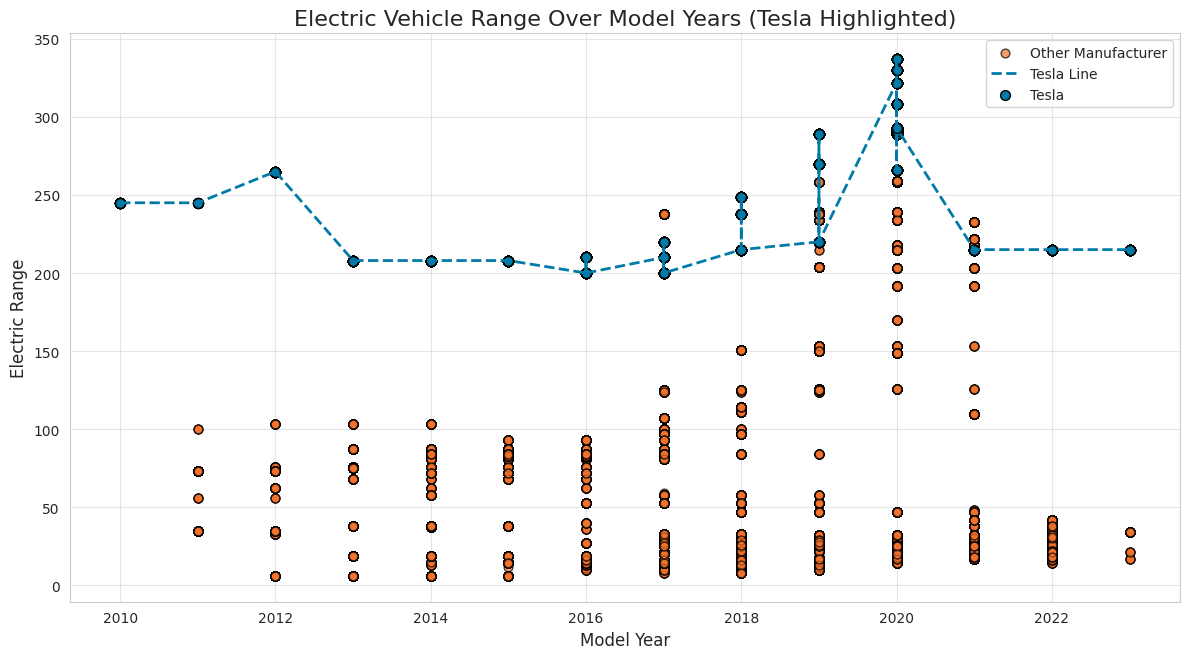

In [220]:
plot_relational_ev_range_vs_year(df)

In [221]:
# ----------------------------------------
# Plot 2: Categorical Graph(Bar Chart)
# ----------------------------------------
def plot_categorical_top_ev_makes(df: pd.DataFrame, top_n: int = 10) -> None:
    """
    Horizontal bar chart showing the top N EV manufacturers by number of vehicles.

    Args:
        df (pd.DataFrame): EV dataset with a 'manufacturer' column.
        top_n (int): Number of top manufacturers to display.
    """

    #  Get top N manufacturers
    df_top, top_manus, _ = top_manufacturers(df, 'manufacturer', top_n)


    # Aggregate vehicle counts per manufacturer
    top_makes = (
        df_top.groupby('manufacturer')
        .size()
        .reset_index(name='Number of Vehicles')
        .sort_values(by='Number of Vehicles', ascending=False)
    )


    # Plot horizontal bar chart

    plt.figure(figsize=(12, 6.7))
    sns.set_style("whitegrid")

    ax = sns.barplot(
        data=top_makes,
        x='Number of Vehicles',
        y='manufacturer',
        order=top_makes['manufacturer'],
        palette='viridis',
        edgecolor='black',
        linewidth=0.7
    )

    plt.title('Top EV Manufacturers by Registration', fontsize=18, fontweight='bold')
    plt.xlabel('Number of Vehicles Registered', fontsize=14, fontweight='semibold')
    plt.ylabel('Manufacturer', fontsize=14, fontweight='semibold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.box(False)


    # Annotate bars with counts

    for patch in ax.patches:
        width = patch.get_width()
        y_pos = patch.get_y() + patch.get_height() / 2
        ax.annotate(
            f'{int(width):,}',
            (width, y_pos),
            ha='left',
            va='center',
            fontsize=10,
            color='black',
            xytext=(5, 0),
            textcoords='offset points'
        )

    plt.tight_layout()
    plt.show()

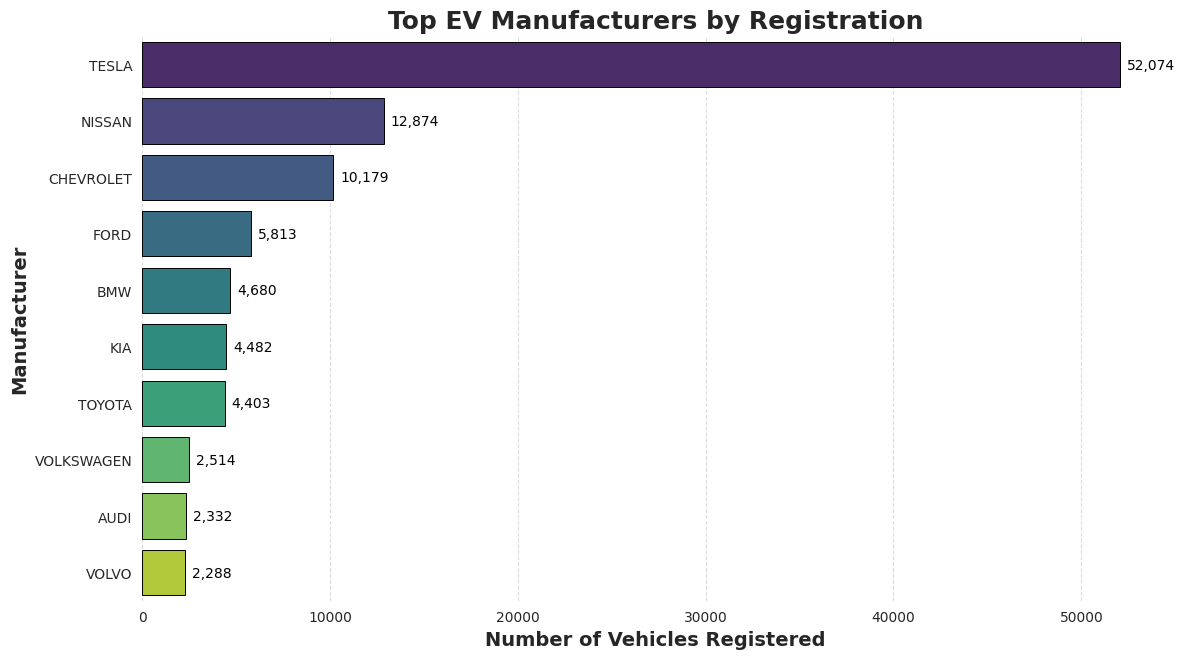

In [222]:
plot_categorical_top_ev_makes(df, 10)

In [223]:
# ----------------------------------------
# Plot 3: Statistical Graph (Violin Plot)
# ----------------------------------------
def plot_statistical_violin(df: pd.DataFrame) -> None:
    """
    Violin plot showing distribution of Electric Range by Electric Vehicle Type.
    """

    plt.figure(figsize=(12, 6.7))
    sns.set_style("whitegrid")

    ax = sns.violinplot(
        data=df,
        x='Electric Vehicle Type',
        y='Electric Range',
        palette='viridis',
        inner='quartile'
    )

    # Increase line width and set colors
    for line_idx, line in enumerate(ax.lines):
        if line_idx % 3 == 0:  # Q1
            line.set_color('black')
            line.set_linewidth(2)
        elif line_idx % 3 == 1:  # Median
            line.set_color('orange')
            line.set_linewidth(4)
        elif line_idx % 3 == 2:  # Q3
            line.set_color('black')
            line.set_linewidth(2)

    stats = df.groupby('Electric Vehicle Type')['Electric Range'].describe()

    # Vertical offsets for annotation
    y_offsets = {'Q1': -8, 'Median': 0, 'Q3': 8}

    for i, vehicle_type in enumerate(stats.index):
        s = stats.loc[vehicle_type]
        Q1, Median, Q3 = int(s['25%']), int(s['50%']), int(s['75%'])

        # Handle overlapping values
        annotations = {}
        if Q1 == Median:
            annotations[f"Q1, Median"] = Q1
            if Q3 != Median:
                annotations["Q3"] = Q3
        elif Q3 == Median:
            annotations["Q1"] = Q1
            annotations[f"Q3, Median"] = Q3
        else:
            annotations = {"Q1": Q1, "Median": Median, "Q3": Q3}

        for name, y in annotations.items():
            offset = y_offsets.get(name.split(',')[0], 0)
            plt.annotate(
                text=f"{name} = {y}",
                xy=(i + 0.30, y),
                xytext=(i + 0.70, y + offset),
                arrowprops=dict(arrowstyle='->', color='black', lw=0.9),
                color='black',
                fontweight='bold',
                va='center'
            )

    plt.title('Electric Range Distribution by Vehicle Type', fontsize=18, fontweight='bold')
    plt.xlabel('Electric Vehicle Type', fontsize=14)
    plt.ylabel('Electric Range (miles)', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

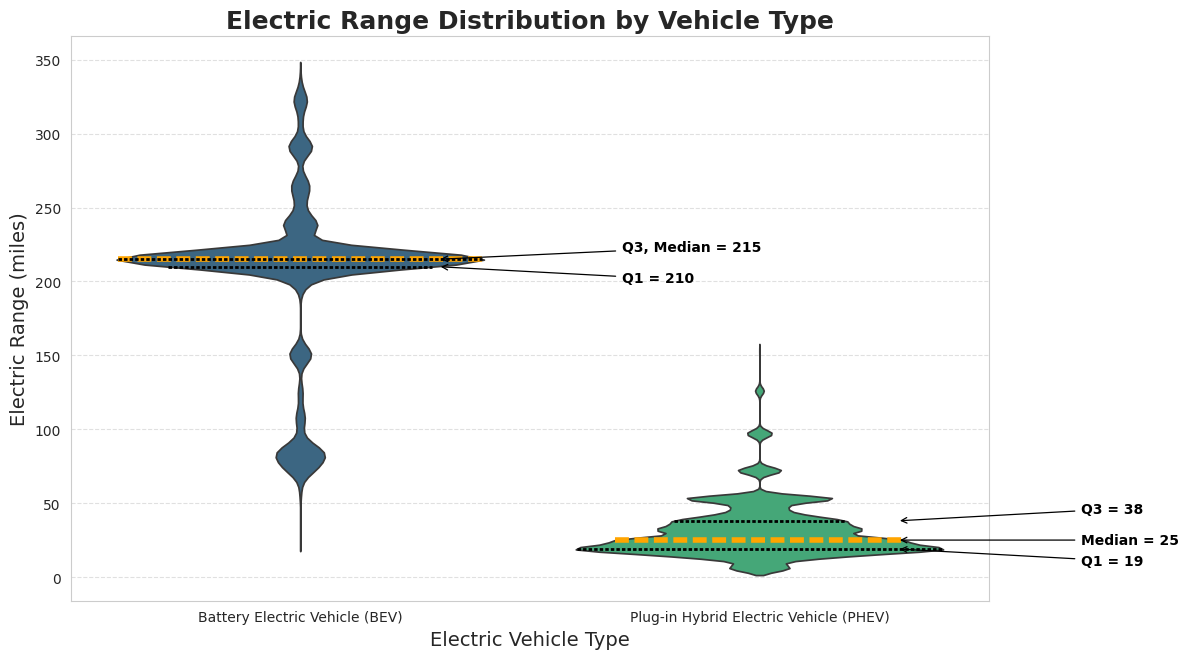

In [224]:
plot_statistical_violin(df)

##Line Fitting - Model Year vs Number of Vehicles

Line fitting helps quantify growth patterns and assess how well different models capture the data's trend.

In [225]:
# -------------------------------
# Helper function : Prepare data
# -------------------------------
def get_vehicle_counts(df):
    """
    Returns x (Model Year) and y (Number of Vehicles) arrays.
    """
    # Aggregate number of vehicles per Model Year
    total_electric = df.pivot_table(index='Model Year', aggfunc='size').reset_index(name='Number of Vehicles')
    x = total_electric['Model Year'].astype(float).values
    y = total_electric['Number of Vehicles'].astype(float).values
    return x, y

# ------------------------------------------------
# Helper function: Plot scatter and fitted lines
# ------------------------------------------------
def plot_fit(x, y, y_fit, label, color, linestyle='-'):
    """
    Plots a fitted line over the scatter plot.
    """
    plt.plot(x, y_fit, color=color, linewidth=2, linestyle=linestyle, label=label)

def plot_base(x, y, title):
    """
    Base scatter plot setup.
    """
    sns.set_style("whitegrid")
    plt.figure(figsize=(10,6))
    plt.scatter(x, y, color='blue', alpha=0.6, label='Observed')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Model Year')
    plt.ylabel('Number of Vehicles')
    plt.grid(True, linestyle='--', alpha=0.6)

In [226]:
# -----------------------------
# 1. Linear Fit
# -----------------------------
def linear_fit(df):
    """
    Perform and visualize a Linear Fit between Model Year and Number of Vehicles.

    Steps:
    - Compute linear regression using scipy.stats.linregress
    - Plot scatter of actual data and linear regression line
    - Display regression equation and R² value
    """

    # Get x (Model Year) and y (Number of Vehicles)
    x, y = get_vehicle_counts(df)

    # Compute linear regression
    slope, intercept, r_value, _, _ = stats.linregress(x, y)
    y_linear = slope * x + intercept
    r2_linear = r_value ** 2

    # Plot scatter and fitted line
    plot_base(x, y, 'Linear Fit: Model Year vs Number of Vehicles')
    plot_fit(x, y, y_linear, f'Linear Fit (R²={r2_linear:.3f})', 'green')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print regression equation and R²
    print(f"Linear Fit: y = {slope:.2f} * x + {intercept:.2f} | R² = {r2_linear:.4f}")

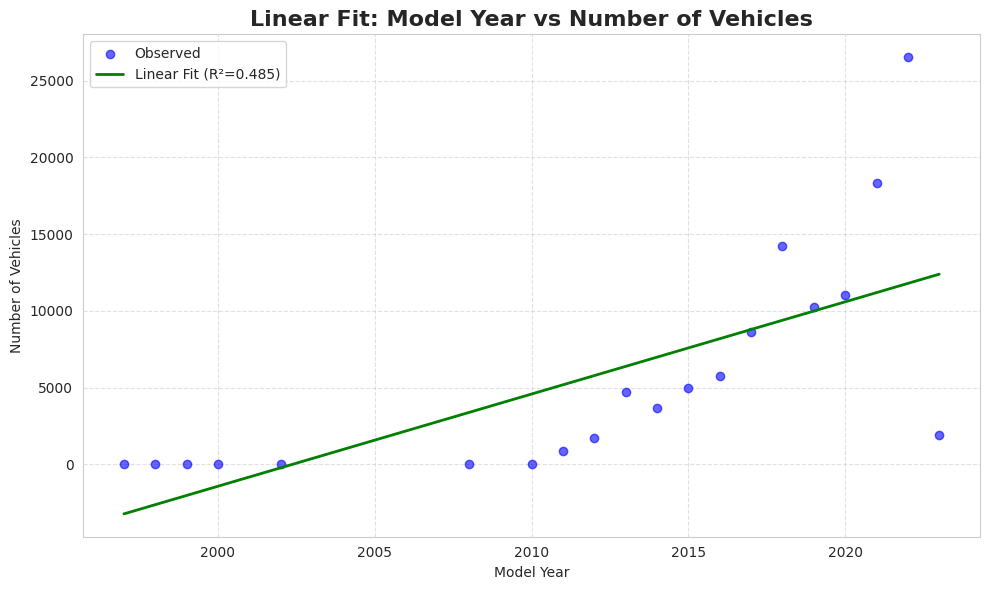

Linear Fit: y = 600.76 * x + -1202947.08 | R² = 0.4851


In [227]:
linear_fit(df)

In [228]:
# -----------------------------
# 2. Exponential Fit
# -----------------------------

def exponential_fit(df):
    """
    Perform and visualize an Exponential Fit between Model Year and Number of Vehicles.

    Steps:
    - Normalize the Model Year to avoid large exponent values
    - Fit exponential model: y = a * exp(b * x)
    - Plot scatter of actual data and exponential curve
    - Display model parameters and R² value
    """

    # Get x (Model Year) and y (Number of Vehicles)
    x, y = get_vehicle_counts(df)
    x_norm = x - x.min()  # normalize to avoid large exponent values

    # Define exponential function
    def exp_func(x, a, b):
        return a * np.exp(b * x)

    # Fit exponential curve
    popt, _ = curve_fit(exp_func, x_norm, y, p0=(y[0], 0.01), maxfev=10000)
    y_exp = exp_func(x_norm, *popt)
    a_fit, b_fit = popt
    r2_exp = r2_score(y, y_exp)

    # Plot scatter and fitted exponential curve
    plot_base(x, y, 'Exponential Fit: Model Year vs Number of Vehicles')
    plot_fit(x, y, y_exp, f'Exponential Fit (R²={r2_exp:.3f})', 'red')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print equation and R² value
    print(f"Exponential Fit: y = {a_fit:.2f} * exp({b_fit:.5f} * (x - {x.min()})) | R² = {r2_exp:.4f}")

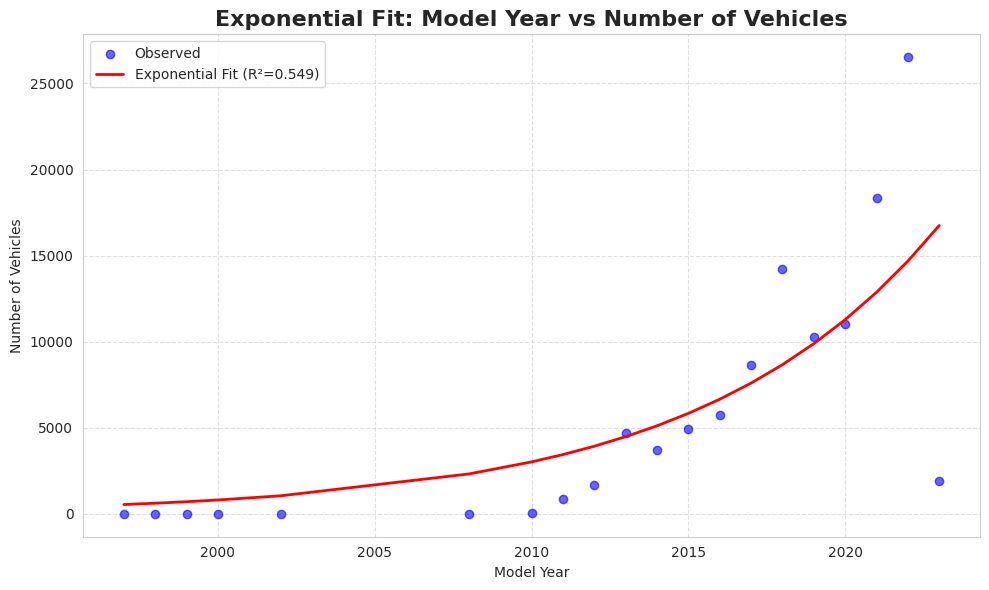

Exponential Fit: y = 544.55 * exp(0.13178 * (x - 1997.0)) | R² = 0.5487


In [229]:
exponential_fit(df)

In [230]:
# ----------------------------------
# 3. Polynomial Fits (Degree 2 & 3)
# ----------------------------------
def polynomial_fit(df):
    """
    Perform and visualize Polynomial Fits (Degree 2 & 3)
    between Model Year and Number of Vehicles.

    Steps:
    - Fit 2nd and 3rd degree polynomial regression models
    - Plot scatter of actual data with both fitted curves
    - Display polynomial coefficients and R² values
    """

    # Get x (Model Year) and y (Number of Vehicles)
    x, y = get_vehicle_counts(df)

    # Degree 2 polynomial
    coeffs_deg2 = np.polyfit(x, y, deg=2)
    y_deg2 = np.polyval(coeffs_deg2, x)
    r2_deg2 = r2_score(y, y_deg2)

    # Degree 3 polynomial
    coeffs_deg3 = np.polyfit(x, y, deg=3)
    y_deg3 = np.polyval(coeffs_deg3, x)
    r2_deg3 = r2_score(y, y_deg3)

    # Plot scatter and fitted polynomial curves
    plot_base(x, y, 'Polynomial Fits: Model Year vs Number of Vehicles')
    plot_fit(x, y, y_deg2, f'Polynomial Deg2 (R²={r2_deg2:.3f})', 'orange')
    plot_fit(x, y, y_deg3, f'Polynomial Deg3 (R²={r2_deg3:.3f})', 'purple')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print coefficients and performance
    print(f"Polynomial Degree 2 Coefficients: {coeffs_deg2} | R² = {r2_deg2:.4f}")
    print(f"Polynomial Degree 3 Coefficients: {coeffs_deg3} | R² = {r2_deg3:.4f}")

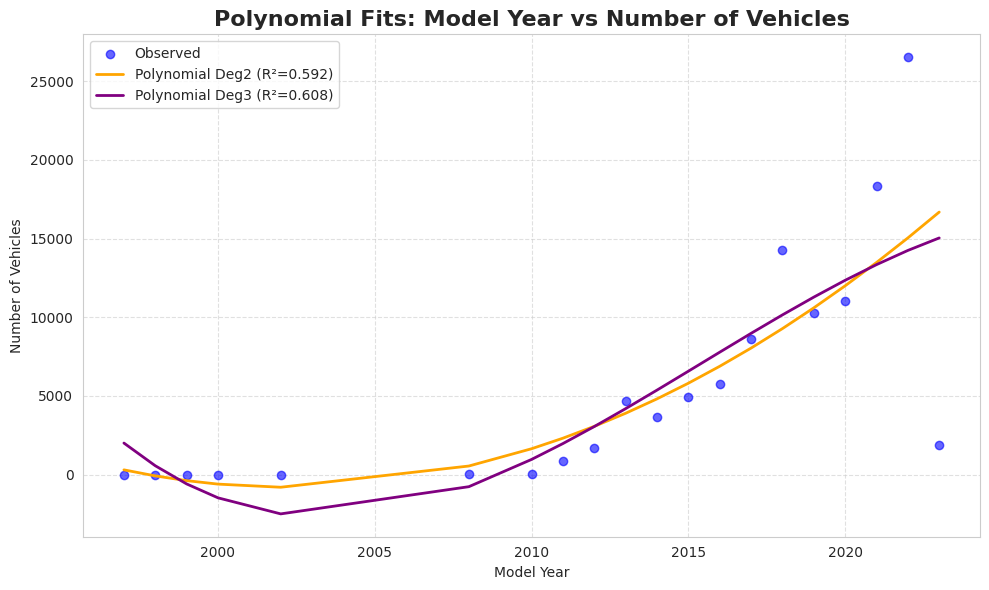

Polynomial Degree 2 Coefficients: [ 4.05215560e+01 -1.62266639e+05  1.62446455e+08] | R² = 0.5917
Polynomial Degree 3 Coefficients: [-2.75234679e+00  1.66413652e+04 -3.35380528e+07  2.25294177e+10] | R² = 0.6081


In [231]:
polynomial_fit(df)

## K-Means Clustering - EV Range vs Base MSRP

Segments data into distinct groups based on feature similarity.

In [232]:
# -----------------------------
# 1. Clean data
# -----------------------------
# Keep EVs with valid range and reasonable price range

df_clean = df[
    (df['Electric Range'] > 10) &
    (df['Base MSRP'] > 1000) &
    (df['Base MSRP'] < 150000)
].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")

Original dataset: 112610 rows
Cleaned dataset: 111457 rows


In [233]:
# -----------------------------
# 2. Prepare features
# -----------------------------
# Select and standardize relevant numerical columns
X = df_clean[['Electric Range', 'Base MSRP']].astype(float).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [234]:
# -----------------------------
# 3. Run K-Means
# -----------------------------
# Apply K-Means clustering (k = 3)
k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)

In [235]:
# -----------------------------
# 4. Interpret clusters
# -----------------------------
def interpret_clusters(df_clean):
    """
    Summarize and interpret EV clusters with progressive range-based labels.
    """

    # Summarize each cluster
    cluster_summary = (
        df_clean
        .groupby('Cluster')[['Electric Range', 'Base MSRP']]
        .agg(['count','mean','min','max'])
        .round(1)
    )

    # Assign progressive descriptive labels
    cluster_labels_desc = {}
    for cluster in cluster_summary.index:
        mean_range = cluster_summary.loc[cluster, ('Electric Range','mean')]
        if mean_range < 50:
            desc = "Low–Mid"
        elif mean_range < 100:
            desc = "Mid–High"
        elif mean_range < 200:
            desc = "High–UltraHigh"
        else:
            desc = "UltraHigh"
        cluster_labels_desc[cluster] = desc

    # Map cluster descriptions back to dataframe
    df_clean['Cluster Description'] = df_clean['Cluster'].map(cluster_labels_desc)

    # Add description to summary
    cluster_summary['Description'] = [cluster_labels_desc[i] for i in cluster_summary.index]

    display(cluster_summary)

    return cluster_labels_desc


In [236]:
# Get the mapping
cluster_labels_desc = interpret_clusters(df_clean)

Electric Range                  Base MSRP                          \
                 count   mean  min  max     count     mean    min     max   
Cluster                                                                     
0                72297  223.2  149  337     72297  59900.0  59900   59900   
1                36370   49.1   11  126     36370  59828.2  52650   64950   
2                 1154   61.1   12  111      1154  35770.3  31950   45600   
3                 1636  199.2   14  245      1636  72027.1  69900  110950   

            Description  
                         
Cluster                  
0             UltraHigh  
1               Low–Mid  
2              Mid–High  
3        High–UltraHigh

In [237]:
# -----------------------------
#  5. Visualize clusters
# -----------------------------
def visualize_clusters(df_clean, kmeans, cluster_labels_desc):
    """
    Visualize EV clusters using Electric Range and Base MSRP,
    with centroid labels for clarity.
    """

    # Set up figure and style
    cluster_colors = [
    '#4b6f44',  # muted green
    '#6b4b77',  # muted purple
    '#8b5e3c',  # muted brown/orange
    '#4b7f8b'   # muted teal
    ]
    plt.figure(figsize=(10, 6.7))
    sns.set_style("whitegrid")

    # Scatter plot for each cluster
    for cluster in df_clean['Cluster'].unique():
        cluster_data = df_clean[df_clean['Cluster'] == cluster]
        plt.scatter(
            cluster_data['Electric Range'],
            cluster_data['Base MSRP'],
            color=cluster_colors[cluster % len(cluster_colors)],
            s=50,
            alpha=0.6,
            label=cluster_labels_desc.get(cluster, f"Cluster {cluster}")
        )

    # Plot centroids
    centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
    plt.scatter(
        centroids_orig[:, 0],
        centroids_orig[:, 1],
        c='red',
        s=200,
        marker='X',
        label='Centroids'
    )

    # Annotate centroid labels with arrows
    for i, (x_c, y_c) in enumerate(centroids_orig):
        label = cluster_labels_desc.get(i, f"Cluster {i}")
        plt.annotate(
            label,
            xy=(x_c, y_c),                 # point (centroid)
            xytext=(x_c + 10, y_c + 10000),  # offset text position
            textcoords='data',
            fontsize=10,
            color='black',
            fontweight='bold',
            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1,
                shrinkA=0,
                shrinkB=5
            ),
        )
    # Finalize and display plot
    plt.xlabel("Electric Range (miles)", fontsize=12)
    plt.ylabel("Base MSRP ($)", fontsize=12)
    plt.title("EV Clusters: Budget / Mid-range / Premium", fontsize=16, fontweight='bold')
    plt.legend(title="Cluster Type")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

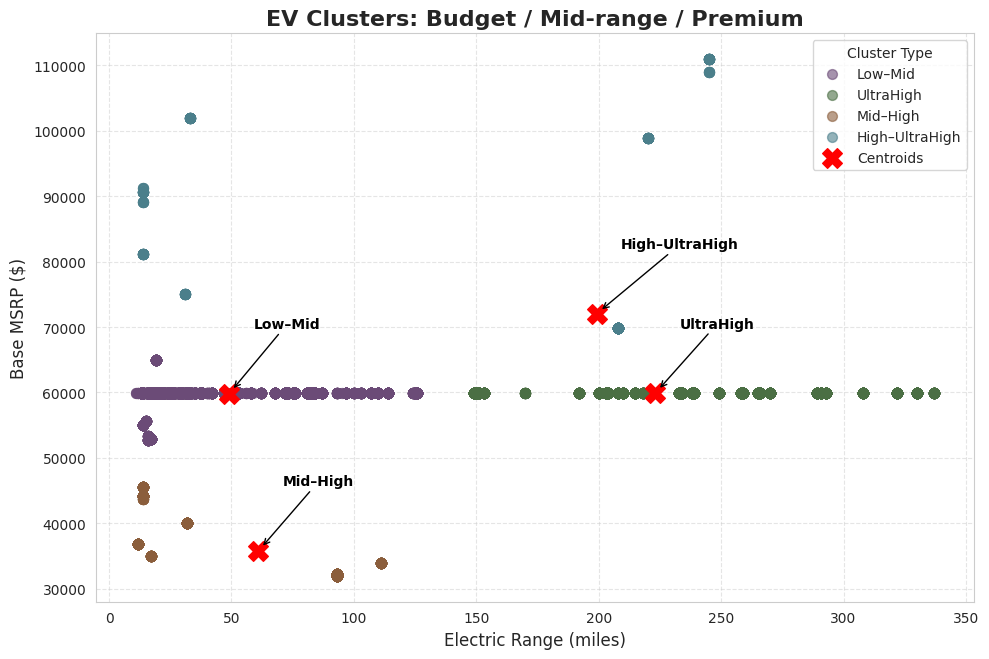

In [238]:
# Visualize
visualize_clusters(df_clean, kmeans, cluster_labels_desc)

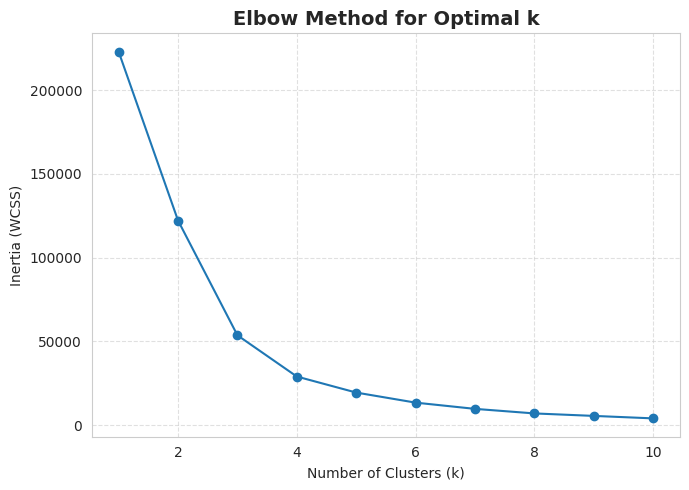

[(1, 222913.99999992756),
 (2, 122101.39992702636),
 (3, 53579.28110735464),
 (4, 28952.704401105137),
 (5, 19385.69283575926)]

In [239]:
# -----------------------------
# 6. Elbow Method Function
# -----------------------------
def plot_elbow(X_scaled, k_min=1, k_max=10):
    """
    Plot the Elbow Method to determine the optimal number of clusters.
    """
    inertias, ks = [], list(range(k_min, k_max + 1))

    for kval in ks:
        km = KMeans(n_clusters=kval, n_init=10, random_state=42).fit(X_scaled)
        inertias.append(km.inertia_)

    #Set up figure and style
    plt.figure(figsize=(7, 5))
    plt.plot(ks, inertias, marker="o")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia (WCSS)")
    plt.title("Elbow Method for Optimal k", fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return ks, inertias

ks, inertias = plot_elbow(X_scaled, 1, 10)
list(zip(ks, inertias))[:5]

k, silhouette:
2: 0.758
3: 0.791
4: 0.824
5: 0.827
6: 0.798
7: 0.783


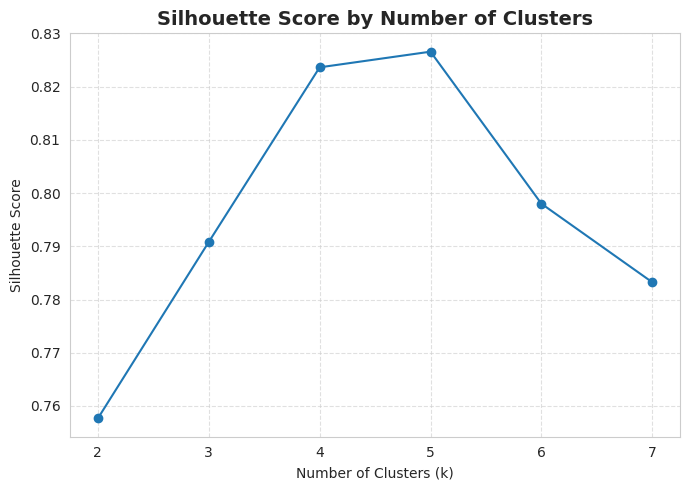

In [240]:
# -----------------------------
# 7. Silhouette Score Function
# -----------------------------
def silhouette_for_range(X_scaled, k_values):
    """
    Calculate silhouette scores for a range of k values.
    """
    results = []
    for kval in k_values:
        if kval < 2:
            results.append((kval, np.nan))
            continue
        km = KMeans(n_clusters=kval, n_init=10, random_state=42)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        results.append((kval, sil))
    return results

#Calculate silhouette scores
k_vals = range(2, 8)
sil_res = silhouette_for_range(X_scaled, k_vals)

print("k, silhouette:")
for k_, s_ in sil_res:
    print(f"{k_}: {s_:.3f}")

#Plot silhouette scores
plt.figure(figsize=(7, 5))
plt.plot([k for k, _ in sil_res], [s for _, s in sil_res], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [241]:
# ------------------------------------------------
# 8. Compare inertia & silhouette for multiple k
# ------------------------------------------------
for kval in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=kval, n_init=10, random_state=42).fit(X_scaled)
    labels = km.labels_
    sil = silhouette_score(X_scaled, labels) if kval >= 2 else np.nan
    print(f"k={kval}: inertia={km.inertia_:.1f}, silhouette={sil:.3f}")

k=2: inertia=122101.4, silhouette=0.758
k=3: inertia=53579.3, silhouette=0.791
k=4: inertia=28952.7, silhouette=0.824
k=5: inertia=19385.7, silhouette=0.827
k=6: inertia=13371.3, silhouette=0.798
